<a href="https://colab.research.google.com/github/davidlealo/practicos_sisrec_2026/blob/main/estudio_m%C3%A9tricas_sistemas_recomendacion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 1. Métricas de Error de Predicción (Ratings Explícitos)

Estas métricas evalúan qué tan cerca estuvo la "nota" que tu sistema predijo frente a la calificación real que el usuario le dio al ítem.

#### Root Mean Squared Error (RMSE)
Es el estándar de la industria para predecir ratings continuos. Al elevar el error al cuadrado, penaliza fuertemente las predicciones que están muy alejadas de la realidad.

$$RMSE = \sqrt{\frac{1}{N}\sum_{i=1}^{N}(\hat{y}_i - y_i)^2}$$

**Implementación en Python:**
```python
import numpy as np

def rmse(y_true, y_pred):
    """
    y_true: array con los ratings reales
    y_pred: array con los ratings predichos
    """
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    
    # Calculamos la raíz de la media de los errores al cuadrado
    return np.sqrt(np.mean((y_true - y_pred)**2))
```

---

### 2. Métricas de Clasificación y Ranking (Top-K)

Estas son fundamentales cuando el objetivo es presentar al usuario una lista con los mejores $K$ ítems, sin importar el rating exacto, sino el orden.

#### Precision@K y Recall@K
Miden qué proporción de los ítems recomendados eran relevantes (Precisión) y qué proporción del total de ítems relevantes logramos capturar en nuestra recomendación (Recall).

* $Precision@K = \frac{|\text{Relevantes} \cap \text{Recomendados en Top } K|}{K}$
* $Recall@K = \frac{|\text{Relevantes} \cap \text{Recomendados en Top } K|}{|\text{Total de Relevantes}|}$

**Implementación en Python:**
```python
def precision_recall_at_k(recommended_items, relevant_items, k=10):
    """
    recommended_items: lista de IDs recomendados ordenados por probabilidad (mayor a menor)
    relevant_items: set o lista de IDs que el usuario realmente consumió
    """
    # Cortamos la lista a los top K
    top_k_recommended = recommended_items[:k]
    
    # Intersección: cuántos de los recomendados eran realmente relevantes
    hits = set(top_k_recommended).intersection(set(relevant_items))
    
    precision = len(hits) / k
    
    # Prevenir división por cero si el usuario en la prueba no tiene ítems relevantes
    recall = len(hits) / len(relevant_items) if len(relevant_items) > 0 else 0.0
    
    return precision, recall
```

#### Normalized Discounted Cumulative Gain (NDCG@K)
Esta es una métrica crucial para evaluar rankings puros. A diferencia de Precision y Recall, el NDCG asume que los aciertos en las primeras posiciones valen mucho más que los aciertos al final de la lista.

El Discounted Cumulative Gain (DCG) se calcula sumando la relevancia de cada ítem, pero "descontada" logarítmicamente según su posición $i$:

$$DCG_K = \sum_{i=1}^{K} \frac{rel_i}{\log_2(i + 1)}$$

El NDCG es simplemente el DCG dividido por el DCG Ideal (IDCG), que es el puntaje máximo posible si el modelo hubiera ordenado los ítems perfectamente de mayor a menor relevancia.

**Implementación en Python:**
```python
def dcg_at_k(relevances, k):
    """
    relevances: array de relevancias (ej. [1, 0, 1, 0, 0]) en el orden predicho por el modelo
    """
    relevances = np.asfarray(relevances)[:k]
    if relevances.size == 0:
        return 0.0
        
    # log2(i+1) donde i es el índice. En Python el índice empieza en 0,
    # por lo que el denominador correcto es log2(i+2)
    discounts = np.log2(np.arange(2, relevances.size + 2))
    return np.sum(relevances / discounts)

def ndcg_at_k(relevances, k):
    # 1. Calcular el DCG de tu modelo
    dcg = dcg_at_k(relevances, k)
    
    # 2. Calcular el DCG ideal (ordenando los aciertos primero)
    ideal_relevances = np.sort(relevances)[::-1]
    idcg = dcg_at_k(ideal_relevances, k)
    
    if idcg == 0.0:
        return 0.0
        
    # 3. Normalizar
    return dcg / idcg
```




$RMSE = \sqrt{\frac{1}{N}\sum_{i=1}^{N}(\hat{y}_i - y_i)^2}$

In [1]:
import numpy as np

def rmse(y_true, y_pred):
  y_true = np.array(y_true)
  y_pred = np.array(y_pred)

  return np.sqrt(np.mean((y_true - y_pred)**2))

In [2]:
y_real = [5, 3, 4, 4]
y_predicho = [4, 3, 4, 5]

# Desglose mental:
# 5 vs 4 -> error de 1 -> al cuadrado es 1
# 3 vs 3 -> error de 0 -> al cuadrado es 0
# 4 vs 4 -> error de 0 -> al cuadrado es 0
# 4 vs 5 -> error de -1 -> al cuadrado es 1
# Promedio de los cuadrados: (1 + 0 + 0 + 1) / 4 = 0.5
# Raíz cuadrada de 0.5 = 0.7071...

error = rmse(y_real, y_predicho)
print(f"El RMSE es: {error:.4f}") # Debería imprimir 0.7071

El RMSE es: 0.7071


¡Perfecto! Ese formato con `$` es el ideal para que tus apuntes de Markdown se vean impecables y profesionales.

Vamos con otra métrica clásica de la misma familia (predicción de ratings), ideal para seguir soltando la mano con la vectorización en `numpy`.

### Mean Absolute Error (MAE)

A diferencia del RMSE que castiga fuertemente los errores grandes (porque eleva la diferencia al cuadrado), el MAE simplemente nos da el promedio directo de las equivocaciones. Es muy útil cuando queremos saber el margen de error "típico" de nuestro modelo en la misma escala de las notas (por ejemplo, poder decirle al negocio: *"nuestro sistema se equivoca por 0.8 estrellas en promedio"*).

La fórmula matemática es:

$MAE = \frac{1}{N}\sum_{i=1}^{N}|\hat{y}_i - y_i|$

**Donde:**
* $N$ es el número total de predicciones.
* $\hat{y}_i$ es el rating predicho por tu sistema.
* $y_i$ es el rating real que dio el usuario.
* $| ... |$ representa el valor absoluto (para que los errores negativos y positivos no se cancelen entre sí).

**Tu misión:**
Escribe la función `def mae(y_true, y_pred):` asumiendo que vas a recibir listas estándar de Python y necesitas hacer el cálculo usando las bondades de `numpy`.

¡Pega tu código aquí cuando lo tengas y lo revisamos!

In [3]:
def mae(y_true, y_pred):
  y_true = np.array(y_true)
  y_pred = np.array(y_pred)

  return np.mean(np.abs(y_true - y_pred))

In [4]:
y_real = [5, 3, 4, 4]
y_predicho = [4, 3, 4, 5]

# Desglose mental para el MAE:
# 5 vs 4 -> error de 1 -> absoluto es 1
# 3 vs 3 -> error de 0 -> absoluto es 0
# 4 vs 4 -> error de 0 -> absoluto es 0
# 4 vs 5 -> error de -1 -> absoluto es 1
# Promedio de los absolutos: (1 + 0 + 0 + 1) / 4 = 0.5

error = mae(y_real, y_predicho)
print(f"El MAE es: {error}") # Imprime 0.5

El MAE es: 0.5


¡Excelente cambio de switch! Pasamos de evaluar "qué nota exacta le pondrá el usuario" a evaluar "¿le achuntamos o no con la lista de recomendaciones?". En el mundo real (y en tu doctorado), estas son las métricas que más le importan a los equipos de producto.

Aquí el concepto de vectorización matemática cambia un poco, porque ya no estamos restando números, sino que estamos haciendo **teoría de conjuntos** (intersecciones) y conteos.

### La lógica detrás del "Top K"

En los sistemas reales, no le muestras al usuario los 10.000 ítems de tu catálogo, le muestras una lista corta (un carrusel de Netflix, por ejemplo). Ese tamaño de la lista es **K**.

* **Precision@K:** De los $K$ ítems que le mostramos, ¿qué porcentaje le interesó realmente? (Mide la "calidad" de tu lista).
* **Recall@K:** De *todos* los ítems que sabemos que al usuario le interesan en el catálogo completo, ¿qué porcentaje logramos atrapar y meter dentro de ese Top $K$? (Mide tu "cobertura").

### La Matemática

$Precision@K = \frac{|\text{Relevantes} \cap \text{Recomendados en Top } K|}{K}$

$Recall@K = \frac{|\text{Relevantes} \cap \text{Recomendados en Top } K|}{|\text{Total de Relevantes}|}$

*(Nota: Los palitos $|...|$ aquí significan "cantidad de elementos", no valor absoluto).*

### Tu misión

Vas a escribir la función `def precision_recall_at_k(recomendados, relevantes, k):` que retorne ambos valores.

**Las reglas del juego para la prueba:**
1.  Recibes `recomendados`: Un arreglo de NumPy ordenado de mayor a menor probabilidad (el primer ítem es tu mejor recomendación).
2.  Recibes `relevantes`: Un arreglo de NumPy con los ítems que sabemos que al usuario le gustaron (el "ground truth").
3.  Corta la lista de `recomendados` hasta el índice $k$.
4.  Encuentra cuántos elementos se cruzan (intersección) entre ese Top $K$ y los `relevantes`. En NumPy, la función salvavidas para esto es `np.intersect1d(arreglo1, arreglo2)`.
5.  Calcula ambas métricas. **Ojo con una trampa clásica de las pruebas:** ¿Qué pasa si el arreglo `relevantes` viene vacío porque el usuario es nuevo y no tiene historial? ¡Evita que tu código explote por división por cero en el Recall!

Aquí tienes los datos de prueba para que los uses en tu código:

```python
import numpy as np

# IDs de los ítems
recomendados = np.array([101, 204, 309, 411, 599])
relevantes = np.array([204, 599, 888, 999])
k = 3

# Desglose mental para K=3:
# Tu Top 3 es: [101, 204, 309]
# Los relevantes son: [204, 599, 888, 999]
# La intersección en el Top 3 es solo el ítem 204 (1 acierto).
# Precision@3 = 1 / 3 = 0.333...
# Recall@3 = 1 / 4 = 0.25
```

¡Escribe tu código, pégalo aquí y lo revisamos a fondo!

**Voy a hacer primero**
$Precision@K = \frac{|\text{Relevantes} \cap \text{Recomendados en Top } K|}{K}$


In [6]:
def precision_at_k(recomendados, relevantes, k):
    # Cortamos la lista al Top K
    top_k = recomendados[:k]

    # Buscamos cuántos aciertos tuvimos
    interseccion = np.intersect1d(top_k, relevantes)

    # Calculamos la precisión
    return len(interseccion) / k

In [7]:
import numpy as np

# IDs de los ítems
recomendados = np.array([101, 204, 309, 411, 599])
relevantes = np.array([204, 599, 888, 999])
k = 3

# Desglose mental para K=3:
# Tu Top 3 es: [101, 204, 309]
# Los relevantes son: [204, 599, 888, 999]
# La intersección en el Top 3 es solo el ítem 204 (1 acierto).
# Precision@3 = 1 / 3 = 0.333...
# Recall@3 = 1 / 4 = 0.25

In [8]:
precision_at_k(recomendados, relevantes, k)

0.3333333333333333

**Voy a hacer segundo**
$Recall@K = \frac{|\text{Relevantes} \cap \text{Recomendados en Top } K|}{|\text{Total de Relevantes}|}$


In [9]:
def recall_at_k(relevantes, recomendados, k):
  top_k = recomendados[:k]
  interseccion = np.intersect1d(top_k, relevantes)

  if len(relevantes) == 0:
    return 0.0

  return len(interseccion) / len(relevantes)

In [10]:
recall_at_k(relevantes, recomendados, k)

0.25

¡Vamos por ese jefe final! El **NDCG@K** (Normalized Discounted Cumulative Gain) impone respeto porque penaliza el orden.

En Precision y Recall, te daba lo mismo si el ítem relevante estaba en el primer lugar o en el último del Top K; valían lo mismo. El NDCG dice: *"No, si el usuario tiene que hacer scroll para encontrar lo que le gusta, tu modelo es peor"*.

Para lograr esto, la métrica usa un logaritmo en el denominador para "descontar" el puntaje a medida que bajamos en la lista. Se calcula en 3 pasos:

### 1. El DCG (Discounted Cumulative Gain)
Es la suma de los aciertos, pero dividiendo cada acierto por el logaritmo de su posición.

$$DCG@K = \sum_{i=1}^{K} \frac{rel_i}{\log_2(i + 1)}$$

* $rel_i$: Es la relevancia del ítem en la posición $i$. En tu caso, será `1` si el ítem recomendado está en la lista de relevantes, y `0` si no.
* $i$: Es la posición en el ranking (1, 2, 3... hasta K). *Nota: le sumamos 1 al índice porque $\log_2(1) = 0$ y no queremos dividir por cero en la primera posición.*

### 2. El IDCG (Ideal DCG)
Es el máximo puntaje posible. Se calcula tomando la misma cantidad de aciertos que tuviste, pero imaginando que tu modelo fue perfecto y **los puso todos en los primeros lugares**.

$$IDCG@K = \sum_{i=1}^{K} \frac{rel_{ideal\_i}}{\log_2(i + 1)}$$

### 3. El NDCG (La normalización)
Para que la nota final sea siempre un número entre 0 y 1, simplemente divides tu puntaje por el puntaje perfecto:

$$NDCG@K = \frac{DCG@K}{IDCG@K}$$

Antes de pasar al código, juega un segundo con esta herramienta para que veas visualmente cómo el logaritmo "castiga" los aciertos tardíos frente a los aciertos en las primeras posiciones:

```json?chameleon
{"component":"LlmGeneratedComponent","props":{"height":"600px","prompt":"Objective: Create an interactive visualizer for NDCG@K (Normalized Discounted Cumulative Gain). Data State: K = 5 positions. Strategy: Form Layout. Inputs: 5 switches or checkboxes representing the 5 recommended ranking positions (Posición 1 to Posición 5). The user toggles if the item at that position is 'Relevante' (1) or 'No Relevante' (0). Behavior: Real-time calculation of DCG, IDCG, and NDCG based on the toggles. Display a visual breakdown showing the math for each active position: 1 / log2(position + 1). For example, show that position 1 yields 1.0 points, position 2 yields 0.63 points, position 3 yields 0.5 points, etc. Clearly show how the Ideal DCG (IDCG) rearranges the active 'Relevante' items to the very top positions to calculate the maximum possible score, and finally divide DCG by IDCG for the NDCG result. All text, titles, and labels must be in Spanish.","id":"im_20e5e0a606a426a4"}}
```

### Tu misión en Python

Escribir esta métrica requiere un paso previo: transformar tus listas de IDs en una matriz de `1`s y `0`s (relevancias).
El truco de magia en `numpy` para hacer esto sin usar un ciclo `for` es `np.isin()`.

```python
recomendados = np.array([101, 204, 309, 411])
relevantes = np.array([204, 411])

# Esto verifica qué recomendados están en la lista de relevantes
# y .astype(float) transforma los True/False en 1.0 y 0.0
relevancias = np.isin(recomendados, relevantes).astype(float)

print(relevancias)
# Resultado: [0., 1., 0., 1.] -> Fallaste el 1ro, achuntaste el 2do, fallaste el 3ro, achuntaste el 4to.
```

**Con ese truco bajo la manga, te toca programar:**
Intenta escribir la función `def ndcg_at_k(recomendados, relevantes, k):`.
*Pista:* `np.arange(2, k + 2)` te sirve para generar los números del denominador del logaritmo de una sola vez, y `np.log2()` te saca el logaritmo de todo el arreglo.

¡Pega tu intento y lo depuramos!

In [11]:
recomendados = np.array([101, 204, 309, 411])
relevantes = np.array([204, 411])

# Esto verifica qué recomendados están en la lista de relevantes
# y .astype(float) transforma los True/False en 1.0 y 0.0
relevancias = np.isin(recomendados, relevantes).astype(float)

print(relevancias)
# Resultado: [0., 1., 0., 1.] -> Fallaste el 1ro, achuntaste el 2do, fallaste el 3ro, achuntaste el 4to.

[0. 1. 0. 1.]


In [14]:
import numpy as np

def dcg_at_k(relevances, k):
    """
    relevances: array de relevancias (ej. [1, 0, 1, 0, 0])
    """
    # ¡Aquí está la corrección clave para NumPy 2.0+!
    relevances = np.asarray(relevances, dtype=float)[:k]

    if relevances.size == 0:
        return 0.0

    discounts = np.log2(np.arange(2, relevances.size + 2))
    return np.sum(relevances / discounts)

def ndcg_at_k(relevances, k):
    # 1. Calcular el DCG de tu modelo
    dcg = dcg_at_k(relevances, k)

    # 2. Calcular el DCG ideal (ordenando los aciertos primero)
    ideal_relevances = np.sort(relevances)[::-1]
    idcg = dcg_at_k(ideal_relevances, k)

    if idcg == 0.0:
        return 0.0

    # 3. Normalizar
    return dcg / idcg

In [15]:
dcg_at_k(relevantes, 2)

np.float64(463.31212871786903)

In [16]:
ndcg_at_k(relevantes, 2)

np.float64(0.8584469664048655)

Es completamente normal y es un síntoma de los tiempos que corren. Los asistentes de código como el de Colab o Copilot son herramientas fantásticas para la productividad, pero actúan como "rueditas de entrenamiento". Cuando te las quitan para una prueba, es natural sentir vértigo porque falta la memoria muscular de la sintaxis.

La mejor forma de soltar la mano y ganar confianza pura es hacer "gimnasia" de arreglos sin bucles `for`. Vamos a hacer un circuito de entrenamiento. Iremos de menos a más, enfocados en la lógica que se usa por debajo en los sistemas de recomendación.

### Nivel 1: Filtrado y Máscaras Booleanas

En los sistemas de recomendación, a menudo necesitamos convertir ratings explícitos (1 a 5 estrellas) en interacciones binarias (relevante o no relevante). Por ejemplo, podríamos decidir que solo las películas con nota 4 o 5 son "relevantes" para el usuario.

**El Desafío:**
Escribe una función que reciba un arreglo de notas y un valor de corte (umbral). La función debe devolver un nuevo arreglo **solo con los números que sean mayores o iguales a ese umbral**.

**Regla de oro:** ¡Cero ciclos `for`! Tienes que usar la lógica de filtrado directo de NumPy (a veces llamado *boolean indexing* o máscaras).

**Tu punto de partida:**
```python
import numpy as np

def filtrar_relevantes(ratings, umbral):
    ratings = np.array(ratings)
    
    # Escribe tu lógica aquí usando NumPy
    resultado = ...
    
    return resultado

# Datos de prueba:
mis_notas = [3, 5, 2, 4, 1, 5, 3]
corte = 4

# Si lo haces bien, print(filtrar_relevantes(mis_notas, corte))
# debería devolver exactamente el arreglo: [5 4 5]
```

¿Te animas a escribir la línea de código que falta para resolver este primer nivel? ¡Pégala aquí y avanzamos al siguiente!

In [23]:
import numpy as np

def filtrar_relevantes(ratings, umbral):
    ratings = np.array(ratings)

    # Escribe tu lógica aquí usando NumPy
    resultado = ratings[ratings >= umbral]

    return resultado

# Datos de prueba:
mis_notas = [3, 5, 2, 4, 1, 5, 3]
corte = 4

# Si lo haces bien, print(filtrar_relevantes(mis_notas, corte))
# debería devolver exactamente el arreglo: [5 4 5]

filtrar_relevantes(mis_notas, corte)

array([5, 4, 5])

In [18]:
import numpy as np

ratings = np.array([3, 5, 2, 4, 1, 5, 3])
umbral = 4

mascara = ratings >= umbral
print(mascara)
# Imprime: [False, True, False, True, False, True, False]

[False  True False  True False  True False]


In [19]:
resultado = ratings[mascara]
print(resultado)
# Imprime: [5, 4, 5] -> ¡Misión cumplida!

[5 4 5]


In [20]:
def filtrar_relevantes(ratings, umbral):
    ratings = np.array(ratings)

    # La máscara booleana filtra el arreglo directamente
    return ratings[ratings >= umbral]

In [22]:
# Datos de prueba:
mis_notas = [3, 5, 2, 4, 1, 5, 3]
corte = 4

filtrar_relevantes(mis_notas, corte)

array([5, 4, 5])

In [6]:
import numpy as np

notas_usuario = np.array([5, 0, 3, 0, 4])

# Escribe tu código aquí para filtrar.
# El resultado debe ser un nuevo arreglo que se vea así: [5, 3, 4]
notas_filtradas = notas_usuario[notas_usuario > 0]

print(notas_filtradas)

[5 3 4]


In [7]:
import numpy as np

predicciones = np.array([3.5, 4.2, 2.8, 5.0, 4.8, 1.2])
umbral = 4.0

# Escribe tu código aquí usando el "colador" de NumPy.
# El resultado debería ser un nuevo arreglo: [4.2, 5.0, 4.8]
buenas_predicciones = predicciones[predicciones >= umbral]

print(buenas_predicciones)

[4.2 5.  4.8]


In [9]:
import numpy as np

y_true = np.array([5, 0, 3, 0, 4])
y_pred = np.array([4, 2, 4, 1, 4])

# 1. Creamos la máscara basada en la realidad (¿dónde hay notas válidas?)
mascara_vistos = y_true > 0

# 2. Usa esa misma máscara para filtrar AMBOS arreglos:
y_true_filtrado = y_true[mascara_vistos]
y_pred_filtrado = y_pred[mascara_vistos]

# 3. Calculamos el error solo con los datos limpios
errores = np.abs(y_true_filtrado - y_pred_filtrado)

print(errores)
# El resultado debería ser: [1 1 0]

[1 1 0]


In [10]:
import numpy as np

# Datos del usuario
items_recomendados = np.array(['A', 'C', 'B', 'D'])
scores_predichos = np.array([4.5, 4.4, 3.9, 2.6])
items_relevantes = np.array(['A', 'B'])

# 1. Crea la máscara: ¿Cuáles de los items_recomendados están en items_relevantes?
mascara_relevantes = np.isin(items_recomendados, items_relevantes)

# 2. Usa la máscara para filtrar los SCORES predichos de los ítems relevantes
scores_relevantes = scores_predichos[mascara_relevantes]

# 3. Usa la máscara INVERTIDA (con ~) para filtrar los SCORES de los ítems NO relevantes ~
scores_no_relevantes = scores_predichos[~mascara_relevantes]

# 4. Imprime los resultados

print("Scores relevantes:", scores_relevantes)       # Debería dar: [4.5 3.9]
print("Scores NO relevantes:", scores_no_relevantes) # Debería dar: [4.4 2.6]

Scores relevantes: [4.5 3.9]
Scores NO relevantes: [4.4 2.6]


In [11]:
import numpy as np

scores_relevantes = np.array([4.5, 3.9])
scores_no_relevantes = np.array([4.4, 2.6])

relevantes_vertical = scores_relevantes.reshape(-1, 1)
matriz_comparacion = relevantes_vertical > scores_no_relevantes

# 1. Cuenta cuántos aciertos (True) hay en la matriz usando np.sum()
aciertos = np.sum(matriz_comparacion)

# 2. Calcula el total de parejas posibles (largo de relevantes multiplicado por largo de no relevantes)
total_parejas = len(scores_relevantes) * len(scores_no_relevantes)

# 3. Calcula el AUC
auc = aciertos / total_parejas

print("El AUC es:", auc)
# Debería imprimir 0.75

El AUC es: 0.75


In [12]:
import numpy as np

def calcular_auc_rapido(ids_recomendados, scores_predichos, ids_relevantes):
    # 1. Separar las aguas (Nivel 3)
    mascara_relevantes = np.isin(ids_recomendados, ids_relevantes)

    scores_relevantes = scores_predichos[mascara_relevantes]
    scores_no_relevantes = scores_predichos[~mascara_relevantes]

    # Prevención de errores: si no hay relevantes o no hay "no relevantes", el AUC es 0
    if len(scores_relevantes) == 0 or len(scores_no_relevantes) == 0:
        return 0.0

    # 2. El cruce de titanes con Broadcasting (Nivel 4)
    matriz_comparacion = scores_relevantes.reshape(-1, 1) > scores_no_relevantes

    # 3. Cálculo final
    aciertos = np.sum(matriz_comparacion)
    total_parejas = len(scores_relevantes) * len(scores_no_relevantes)

    return aciertos / total_parejas

In [13]:
def mae_vistos_python_puro(y_true, y_pred):
    errores = []

    # zip nos entrega la pareja de notas película por película
    for real, pred in zip(y_true, y_pred):
      if real > 0:
        errores.append(abs(real - pred))

        # 1. Escribe un 'if' para verificar que la nota 'real' sea mayor a 0
        # 2. Si se cumple, calcula el error absoluto entre 'real' y 'pred'
        # 3. Guarda ese error en la lista usando errores.append()

        # COMPLETAR AQUÍ
        pass

    # Prevención de error por división por cero
    if len(errores) == 0:
        return 0.0

    # 4. Retorna el promedio (la suma de los errores dividida por la cantidad de errores)
    return sum(errores) / len(errores)

# Datos de prueba
notas_reales = [5, 0, 3, 0, 4]
notas_predichas = [4, 2, 4, 1, 4]

# Al ejecutarlo debería darte 0.666... (que viene de promediar los errores 1, 1 y 0)
print(mae_vistos_python_puro(notas_reales, notas_predichas))

0.6666666666666666


In [15]:
def auc_python_puro(scores_relevantes, scores_no_relevantes):
    aciertos = 0

    # 1. Tomamos un ítem relevante...
    for score_rel in scores_relevantes:

        # 2. Y lo comparamos contra TODOS los no relevantes antes de pasar al siguiente
        for score_no_rel in scores_no_relevantes:

            # 3. La condición de victoria
            if score_rel > score_no_rel:
                aciertos += 1

    # Calculamos el total de combinaciones
    total_parejas = len(scores_relevantes) * len(scores_no_relevantes)

    # Prevención de división por cero
    if total_parejas == 0:
        return 0.0

    return aciertos / total_parejas

# Datos de prueba
scores_rel = [4.5, 3.9]
scores_no_rel = [4.4, 2.6]

print(auc_python_puro(scores_rel, scores_no_rel))
# Ahora sí imprime 0.75

0.75


¡Esa es la actitud de un verdadero investigador! Nada le gana a la memoria muscular que se construye haciendo ejercicios.

Para este "simulacro final", vamos a mezclar lo que ya sabes y te voy a poner un par de trampas clásicas que los profesores adoran poner en las pruebas de Sistemas de Recomendación.

Puedes elegir resolverlos usando la **vía rápida de NumPy** o el **"Plan B" de Python puro**. ¡Usa lo que te haga sentir más cómodo!

---

### Ejercicio 1: El paso previo (Binarización)

En la teoría de tu prueba te preguntan por métricas como AUC y MAP. Estas métricas asumen que un ítem es "Relevante" (1) o "No Relevante" (0). Pero en la vida real, los datasets como MovieLens (el que usa tu prueba) vienen con notas de 1 a 5.

**Tu misión:**
Escribe una función que reciba un arreglo de notas de 1 a 5, y un `umbral` (por ejemplo, 3.5). La función debe devolver una lista o arreglo compuesto **estrictamente de `1`s y `0`s**, donde `1` significa que la nota era mayor o igual al umbral.

```python
import numpy as np

def binarizar_notas(notas, umbral):
    # Escribe tu lógica aquí
    pass

# Datos de prueba
mis_notas = [5, 2, 4, 1, 3]
umbral = 4

# El resultado esperado debe ser exactamente: [1, 0, 1, 0, 0]
print(binarizar_notas(mis_notas, umbral))
```

---

### Ejercicio 2: Cazando el Bug (Precisión con trampa)

Un compañero de curso intentó implementar la métrica `precision_at_k` en Python puro (sin NumPy) para un usuario que solo tiene un ítem relevante, pero su código a veces explota y otras veces da resultados matemáticamente imposibles (como una precisión mayor a 1.0).

**Tu misión:**
Encuentra los **dos errores lógicos/conceptuales** en su código y reescribe la función para que funcione a la perfección.

```python
def precision_at_k_bug(recomendados, relevantes, k):
    aciertos = 0
    
    # Toma los top K
    top_k = recomendados[:k]
    
    # Revisa los aciertos
    for rec in top_k:
        for rel in relevantes:
            if rec == rel:
                aciertos += 1
                
    # Calcula la precisión
    precision = aciertos / len(relevantes)
    
    return precision

# Datos de prueba
recomendados = ['Item_A', 'Item_B', 'Item_C', 'Item_D']
relevantes = ['Item_B']
k = 2

# El Top 2 es ['Item_A', 'Item_B'].
# 'Item_B' es un acierto.
# La precisión en K=2 debería ser 1 acierto / 2 recomendados = 0.5
print(precision_at_k_bug(recomendados, relevantes, k))
```

---

### Ejercicio 3: El desafío MAP (Average Precision)

En la primera pregunta teórica de tu interrogación te piden explicar el **MAP (Mean Average Precision)**. El MAP es simplemente calcular el *Average Precision (AP)* de cada usuario y luego promediarlos.

El **AP** se calcula así: Revisas tu lista de recomendaciones de arriba hacia abajo. **Solo cuando te encuentras con un acierto**, calculas la precisión hasta ese punto. Al final, promedias todas esas precisiones.

*Ejemplo mental:*
* Recomiendas: `[A, B, C]`
* Relevantes: `[A, C]`
* Posición 1 (A): Es acierto. Precisión hasta aquí: 1/1 = 1.0
* Posición 2 (B): Falla. No calculamos nada.
* Posición 3 (C): Es acierto. Precisión hasta aquí: 2/3 = 0.66
* **AP** = Promedio de las precisiones en los aciertos = (1.0 + 0.66) / 2 = 0.83

**Tu misión:**
Escribe la función `average_precision`. Te sugiero usar Python puro (un ciclo `for` iterando con `enumerate` para saber en qué posición vas).

```python
def average_precision(recomendados, relevantes):
    suma_precisiones = 0.0
    aciertos_hasta_ahora = 0
    
    # PISTA: usa enumerate(recomendados) para tener la posición (índice) y el ítem
    
    # COMPLETAR AQUÍ
    
    # Prevención de división por cero
    if len(relevantes) == 0:
        return 0.0
        
    return suma_precisiones / len(relevantes)

# Datos de prueba
recomendaciones = ['A', 'B', 'C']
items_relevantes = ['A', 'C']

# Debería dar approx 0.833...
print(average_precision(recomendaciones, items_relevantes))
```

¡Elige uno para empezar, pega tu código y lo revisamos a nivel de "corrección de prueba"!

In [17]:
import numpy as np

def binarizar_notas(notas, umbral):
    for i in range(len(notas)):
        if notas[i] >= umbral:
            notas[i] = 1
        else:
          notas[i] = 0
    return notas

# Datos de prueba
mis_notas = [5, 2, 4, 1, 3]
umbral = 4

# El resultado esperado debe ser exactamente: [1, 0, 1, 0, 0]
print(binarizar_notas(mis_notas, umbral))

[1, 0, 1, 0, 0]


In [19]:
def precision_at_k_arreglado(recomendados, relevantes, k):
    aciertos = 0
    top_k = recomendados[:k]

    # Seguro contra división por cero
    if len(top_k) == 0:
        return 0.0

    for rec in top_k:
        for rel in relevantes:
            if rec == rel:
                aciertos += 1

    precision = aciertos / len(top_k)

    return precision

# Datos de prueba
recomendados = ['Item_A', 'Item_B', 'Item_C', 'Item_D']
relevantes = ['Item_B']
k = 2

print(precision_at_k_arreglado(recomendados, relevantes, k))

0.5


In [20]:
def average_precision(recomendados, relevantes):
    suma_precisiones = 0.0
    aciertos_hasta_ahora = 0

    # PISTA: usa enumerate(recomendados) para tener la posición (índice) y el ítem
    for posicion, item in enumerate(recomendados):
        if item in relevantes:
            aciertos_hasta_ahora += 1
            suma_precisiones += aciertos_hasta_ahora / (posicion + 1)

    # COMPLETAR AQUÍ

    # Prevención de división por cero
    if len(relevantes) == 0:
        return 0.0

    return suma_precisiones / len(relevantes)

# Datos de prueba
recomendaciones = ['A', 'B', 'C']
items_relevantes = ['A', 'C']

# Debería dar approx 0.833...
print(average_precision(recomendaciones, items_relevantes))

0.8333333333333333


In [5]:
import numpy as np

def precision_estricta_at_k(recomendados_ids, scores_predichos, relevantes_ids, k, umbral=4.0):
    # 1. Corta tus listas para quedarte solo con el Top K
    recomendados_ids = recomendados_ids[:k]
    scores_predichos = scores_predichos[:k]
    # 2. Cuenta cuántos ítems cumplen la doble condición (ser relevantes Y tener score >= umbral)
    aciertos = 0
    for i in range(len(recomendados_ids)):
      for j in range(len(relevantes_ids)):
        if recomendados_ids[i] == relevantes_ids[j] and scores_predichos[i] >= umbral:
          aciertos += 1
    # 3. Retorna los aciertos divididos por k
    return aciertos / k

    # COMPLETAR AQUÍ
    pass

# Datos de prueba
rec_ids = np.array(['A', 'B', 'C', 'D'])
rec_scores = np.array([4.8, 3.5, 4.2, 2.1])
rel_ids = np.array(['B', 'C'])
k = 3

# Análisis mental para K=3:
# Top 3 es ['A', 'B', 'C'] con scores [4.8, 3.5, 4.2].
# ¿'A' es relevante? No. (0 aciertos)
# ¿'B' es relevante? Sí. ¿Su score (3.5) es >= 4.0? No. (0 aciertos) -> ¡Aquí actúa la métrica estricta!
# ¿'C' es relevante? Sí. ¿Su score (4.2) es >= 4.0? Sí. (1 acierto)
# Resultado esperado: 1 acierto / 3 = 0.333...

print(precision_estricta_at_k(rec_ids, rec_scores, rel_ids, k))

0.3333333333333333


In [6]:
def penalizacion_sobre_promesa(notas_reales, notas_predichas):
    errores = []

    # ¿Qué vas a usar aquí? ¿zip o ciclos anidados?
    # COMPLETAR AQUÍ:
    # 1. Recorre las notas.
    # 2. Si la predicha es MAYOR a la real, el error es (predicha - real).
    # 3. Si no, el error es 0.
    # 4. Guarda el error en la lista 'errores'.
    for i in range(len(notas_reales)):
      for j in range(len(notas_predichas)):
        if notas_predichas[j] > notas_reales[i]:
          errores.append(notas_predichas[j] - notas_reales[i])
        else:
          errores.append(0)

    pass

    # Retornamos el promedio de los errores
    if len(errores) == 0:
        return 0.0
    return sum(errores) / len(errores)

# Datos de prueba
y_true = [3.0, 5.0, 2.0, 4.0]
y_pred = [5.0, 4.0, 3.0, 4.0]

# Análisis mental:
# Peli 1 (3 vs 5): ¡Sobre-promesa! Error = 2.0
# Peli 2 (5 vs 4): Sorpresa positiva. Error = 0
# Peli 3 (2 vs 3): ¡Sobre-promesa! Error = 1.0
# Peli 4 (4 vs 4): Exacto. Error = 0
# Promedio: (2.0 + 0 + 1.0 + 0) / 4 = 0.75

print(penalizacion_sobre_promesa(y_true, y_pred))
# Debería imprimir 0.75

0.8125


In [7]:
def penalizacion_sobre_promesa(notas_reales, notas_predichas):
    errores = []

    # "El Cierre": Juntamos la nota real y la predicha de la misma película
    for real, pred in zip(notas_reales, notas_predichas):

        # Si sobre-prometió, calculamos la diferencia
        if pred > real:
            errores.append(pred - real)
        # Si fue humilde o le achuntó exacto, el error es 0
        else:
            errores.append(0)

    # Retornamos el promedio de los errores
    if len(errores) == 0:
        return 0.0
    return sum(errores) / len(errores)

# Datos de prueba
y_true = [3.0, 5.0, 2.0, 4.0]
y_pred = [5.0, 4.0, 3.0, 4.0]

print(penalizacion_sobre_promesa(y_true, y_pred))
# Ahora SÍ imprime 0.75 exacto

0.75


In [9]:
def diversidad_anios(anios_recomendados):
    diferencias = []

    # 1. Toma un año de la lista...
    # 2. Y compáralo contra TODOS los años de la misma lista.
    # 3. Calcula la diferencia absoluta: abs(anio1 - anio2)
    # 4. Agrégala a la lista 'diferencias' usando .append()
    for a in range(len(anios_recomendados)):
      for b in range(len(anios_recomendados)):
          diferencias.append(abs(anios_recomendados[a] - anios_recomendados[b]))

    # COMPLETAR AQUÍ

    # Promedio de las diferencias
    if len(diferencias) == 0:
        return 0.0
    return sum(diferencias) / len(diferencias)

# Datos de prueba
anios_top_3 = [2020, 2010, 2022]

# Debería dar 5.333333333333333
print(diversidad_anios(anios_top_3))

5.333333333333333


In [11]:
def acierto_sentimiento(notas_reales, notas_predichas, umbral=4.0):
    aciertos = 0

    # ¡Usa "El Cierre" aquí!
    # COMPLETAR AQUÍ:
    # 1. Empareja la nota real y la predicha de cada película.
    # 2. Determina si la nota real es Positiva o Negativa según el umbral.
    # 3. Determina si la nota predicha es Positiva o Negativa.
    # 4. Si ambas coinciden en sentimiento (las dos positivas o las dos negativas), suma 1 a 'aciertos'.
    for real, predicha in zip(notas_reales, notas_predichas):
      if real >= umbral and predicha >= umbral:
        aciertos += 1
      elif real < umbral and predicha < umbral:
        aciertos += 1
      else:
        aciertos += 0

    pass

    # Calculamos el porcentaje final
    if len(notas_reales) == 0:
        return 0.0
    return aciertos / len(notas_reales)

# Datos de prueba
y_true = [4.5, 2.0, 5.0, 3.5]
y_pred = [4.1, 3.8, 2.5, 3.0]

# Análisis mental:
# Peli 1 (4.5 y 4.1): Ambas >= 4.0 (Acierto)
# Peli 2 (2.0 y 3.8): Ambas < 4.0 (Acierto)
# Peli 3 (5.0 y 2.5): 5.0 es Positivo, 2.5 es Negativo (Fallo)
# Peli 4 (3.5 y 3.0): Ambas < 4.0 (Acierto)
# Total: 3 aciertos de 4 películas.

print(acierto_sentimiento(y_true, y_pred))
# Debería imprimir 0.75

0.75


In [12]:
import math

def calcular_dcg(relevancias):
    dcg = 0.0
    # 1. Usa enumerate para tener el índice y la relevancia
    # 2. La fórmula es: relevancia / math.log2(indice + 2)
    # 3. Suma eso al dcg total

    # COMPLETAR AQUÍ
    for i, relevancia in enumerate(relevancias):
      dcg += relevancia / math.log2(i + 2)

    pass

    return dcg

def calcular_ndcg(relevancias):
    # 1. Calcula el DCG de la lista tal como viene
    dcg_real = calcular_dcg(relevancias)

    # 2. Crea la lista ideal ordenando 'relevancias' de mayor a menor
    relevancias_ideales = sorted(relevancias, reverse=True)

    # 3. Calcula el DCG de esa lista ideal (este es tu iDCG)
    idcg = calcular_dcg(relevancias_ideales)

    # Prevención de división por cero
    if idcg == 0:
        return 0.0

    # 4. Retorna la normalización
    return dcg_real / idcg

# Datos de prueba
# El modelo recomendó 3 películas. Sus notas reales eran 2, 0 y 5.
# (Puso la mejor película al final, ¡qué mal modelo!)
notas_en_orden_recomendado = [2, 0, 5]

# Análisis mental:
# DCG Real = (2 / log2(2)) + (0 / log2(3)) + (5 / log2(4)) = 2.0 + 0.0 + 2.5 = 4.5
# Orden Ideal = [5, 2, 0]
# iDCG = (5 / log2(2)) + (2 / log2(3)) + (0 / log2(4)) = 5.0 + 1.26... + 0.0 = 6.26...
# nDCG = 4.5 / 6.26... = 0.718...

print("El nDCG es:", calcular_ndcg(notas_en_orden_recomendado))

El nDCG es: 0.7186363722895477


In [14]:
recomendaciones = ['Matrix', 'Shrek', 'Inception']

In [15]:
for peli in recomendaciones:
    print(peli) # Imprime Matrix, Shrek... pero no sabes el índice.

Matrix
Shrek
Inception


In [16]:
for i in range(len(recomendaciones)):
    peli = recomendaciones[i] # Extracción manual molesta
    print(f"Posición {i}: {peli}")

Posición 0: Matrix
Posición 1: Shrek
Posición 2: Inception


In [17]:
recomendaciones = ['Matrix', 'Shrek', 'Inception']

# La magia ocurre aquí: "posicion" atrapa el 0, 1, 2... y "peli" atrapa el texto
for posicion, peli in enumerate(recomendaciones):
    print(f"La película {peli} quedó en el lugar {posicion}")

La película Matrix quedó en el lugar 0
La película Shrek quedó en el lugar 1
La película Inception quedó en el lugar 2


In [18]:
recomendaciones = ['Matrix', 'Shrek', 'Inception']

# quiero que parta por 1
for posicion, peli in enumerate(recomendaciones):
    print(f"La película {peli} quedó en el lugar {posicion + 1}")

La película Matrix quedó en el lugar 1
La película Shrek quedó en el lugar 2
La película Inception quedó en el lugar 3


In [20]:
import math

def calcular_idcg_maximo(recomendaciones_tuplas):
    # 1. Extrae SOLO las notas (relevancias) de las tuplas y ponlas en una lista.
    # 2. Ordena esa nueva lista de mayor a menor.
    # 3. Aplica tu ciclo for con enumerate para calcular el descuento logarítmico.

    idcg = 0.0

    # COMPLETAR AQUÍ
    relevancias = [tupla[1] for tupla in recomendaciones_tuplas]
    relevancias_ordenadas = sorted(relevancias, reverse=True)
    for i, relevancia in enumerate(relevancias_ordenadas, start=1):
        idcg += relevancia / math.log2(i + 1)
    pass

    return idcg

# Datos de prueba: Lista de tuplas (Película, Relevancia Real)
recomendaciones = [
    ("Peli Regular", 1),
    ("Peli Obra Maestra", 5),
    ("Peli Pésima", 0),
    ("Peli Muy Buena", 4)
]

# Análisis mental del "Mundo Ideal":
# Las relevancias sueltas son: [1, 5, 0, 4]
# El orden ideal (mayor a menor) es: [5, 4, 1, 0]
# Fórmula: 5/log2(2) + 4/log2(3) + 1/log2(4) + 0/log2(5)
# Cálculo: 5.0 + 2.523... + 0.5 + 0.0
# Total esperado: ~8.023

print(calcular_idcg_maximo(recomendaciones))

8.023719014285831


In [21]:
import math

def calcular_bpr_loss(scores_positivos, scores_negativos):
    bpr_total = 0.0

    # "El Cierre": Enfrentamos el positivo contra el negativo
    for pos, neg in zip(scores_positivos, scores_negativos):
        # 1. Calculamos la diferencia
        diferencia = pos - neg

        # 2. Pasamos la diferencia por la Sigmoide
        # math.exp(-diferencia) es e^(-x)
        probabilidad = 1 / (1 + math.exp(-diferencia))

        bpr_total += probabilidad

    return bpr_total / len(scores_positivos)

# Datos de prueba
# Apenas le gana por 0.1
print("BPR empate técnico:", calcular_bpr_loss([4.1], [4.0]))
# Le gana por paliza (3.0 de diferencia)
print("BPR victoria aplastante:", calcular_bpr_loss([4.5], [1.5]))

BPR empate técnico: 0.5249791874789399
BPR victoria aplastante: 0.9525741268224334


¡Desafío aceptado! Y me encanta hacia dónde vas, porque pedirte calcular un solo Precision@K o un solo Recall@K es muy fácil para una prueba universitaria. Lo que los profesores suelen pedir es **generar todos los puntos de la curva** de una sola pasada.

Para dibujar esa curva en la vida real, necesitas evaluar tu modelo en $K=1$, luego en $K=2$, luego en $K=3$... y así hasta el final de tu lista.

### El Desafío: "El Trazador de Curvas" 📈

**El Contexto:**
Tu jefe quiere dibujar la Curva Precision-Recall de tu último modelo. Para poder graficarla, necesita que le entregues las coordenadas $(X, Y)$, donde $X$ es el Recall e $Y$ es la Precisión.

**La Regla:**
Debes crear una función que recorra la lista de recomendaciones de arriba hacia abajo. En cada nueva posición (cada nuevo $K$), debes actualizar tus contadores y generar un nuevo punto `(Recall, Precision)`.

**Tu misión:**
Vas a necesitar a tu nuevo mejor amigo, **"El Posicionador" (`enumerate`)**, porque para calcular la Precisión en cada paso, necesitas saber exactamente en qué $K$ (posición) vas.

Aquí tienes la plantilla:

```python
def generar_puntos_pr(recomendados, relevantes):
    puntos_curva = []
    aciertos_hasta_ahora = 0
    total_relevantes = len(relevantes)
    
    # Prevención por si no hay relevantes (para evitar división por cero en Recall)
    if total_relevantes == 0:
        return []

    # ¡Usa El Posicionador aquí!
    # COMPLETAR AQUÍ:
    # 1. Recorre los recomendados usando enumerate para tener el índice y el ítem.
    #    (Ojo: el K actual es igual al índice + 1).
    # 2. Si el ítem está en la lista de relevantes, suma un acierto.
    # 3. Calcula la Precision en este K actual.
    # 4. Calcula el Recall en este K actual.
    # 5. Agrega la tupla (recall, precision) a la lista 'puntos_curva'.
    
    pass

    return puntos_curva

# Datos de prueba
# Tu modelo recomendó 4 películas en este orden exacto:
recomendaciones = ['A', 'B', 'C', 'D']
# Al usuario solo le gustaban la 'A' y la 'C'
peliculas_relevantes = ['A', 'C']

# Análisis mental paso a paso:
# Total relevantes que existen = 2

# K=1 (Evalúas ['A']):
# 'A' es acierto. Aciertos=1.
# Precision = 1/1 = 1.0. Recall = 1/2 = 0.5. --> Punto: (0.5, 1.0)

# K=2 (Evalúas ['A', 'B']):
# 'B' es fallo. Aciertos se mantiene en 1.
# Precision = 1/2 = 0.5. Recall = 1/2 = 0.5. --> Punto: (0.5, 0.5)

# K=3 (Evalúas ['A', 'B', 'C']):
# 'C' es acierto. Aciertos sube a 2.
# Precision = 2/3 = 0.66. Recall = 2/2 = 1.0. --> Punto: (1.0, 0.66)

# K=4 (Evalúas ['A', 'B', 'C', 'D']):
# 'D' es fallo. Aciertos se mantiene en 2.
# Precision = 2/4 = 0.5. Recall = 2/2 = 1.0. --> Punto: (1.0, 0.5)

print(generar_puntos_pr(recomendaciones, peliculas_relevantes))
# Debería imprimir una lista de 4 tuplas:
# [(0.5, 1.0), (0.5, 0.5), (1.0, 0.666...), (1.0, 0.5)]
```

Fíjate en el análisis mental: cuando fallas (K=2 y K=4), la Precisión cae porque agregaste basura, y el Recall se estanca. Cuando aciertas (K=3), el Recall sube y la Precisión se recupera. ¡Ese es el famoso *Trade-off* en acción!

Concéntrate en la lógica matemática dentro del ciclo. ¡Pega tu código cuando estés listo!

In [23]:
def generar_puntos_pr(recomendados, relevantes):
    puntos_curva = []
    aciertos_hasta_ahora = 0
    total_relevantes = len(relevantes)

    # Prevención por si no hay relevantes (para evitar división por cero en Recall)
    if total_relevantes == 0:
        return []

    # ¡Usa El Posicionador aquí!
    # COMPLETAR AQUÍ:
    # 1. Recorre los recomendados usando enumerate para tener el índice y el ítem.
    #    (Ojo: el K actual es igual al índice + 1).
    # 2. Si el ítem está en la lista de relevantes, suma un acierto.
    # 3. Calcula la Precision en este K actual.
    # 4. Calcula el Recall en este K actual.
    # 5. Agrega la tupla (recall, precision) a la lista 'puntos_curva'.
    for posicion, item in enumerate(recomendados):
        if item in relevantes:
            aciertos_hasta_ahora += 1

        precision = aciertos_hasta_ahora / (posicion + 1)
        recall = aciertos_hasta_ahora / total_relevantes
        puntos_curva.append((recall, precision))

    pass

    return puntos_curva

# Datos de prueba
# Tu modelo recomendó 4 películas en este orden exacto:
recomendaciones = ['A', 'B', 'C', 'D']
# Al usuario solo le gustaban la 'A' y la 'C'
peliculas_relevantes = ['A', 'C']

# Análisis mental paso a paso:
# Total relevantes que existen = 2

# K=1 (Evalúas ['A']):
# 'A' es acierto. Aciertos=1.
# Precision = 1/1 = 1.0. Recall = 1/2 = 0.5. --> Punto: (0.5, 1.0)

# K=2 (Evalúas ['A', 'B']):
# 'B' es fallo. Aciertos se mantiene en 1.
# Precision = 1/2 = 0.5. Recall = 1/2 = 0.5. --> Punto: (0.5, 0.5)

# K=3 (Evalúas ['A', 'B', 'C']):
# 'C' es acierto. Aciertos sube a 2.
# Precision = 2/3 = 0.66. Recall = 2/2 = 1.0. --> Punto: (1.0, 0.66)

# K=4 (Evalúas ['A', 'B', 'C', 'D']):
# 'D' es fallo. Aciertos se mantiene en 2.
# Precision = 2/4 = 0.5. Recall = 2/2 = 1.0. --> Punto: (1.0, 0.5)

print(generar_puntos_pr(recomendaciones, peliculas_relevantes))
# Debería imprimir una lista de 4 tuplas:
# [(0.5, 1.0), (0.5, 0.5), (1.0, 0.666...), (1.0, 0.5)]

[(0.5, 1.0), (0.5, 0.5), (1.0, 0.6666666666666666), (1.0, 0.5)]


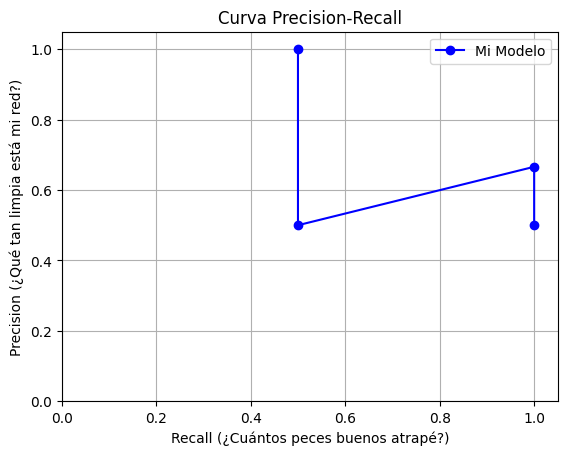

In [24]:
import matplotlib.pyplot as plt

# 1. Estos son los puntos que acaba de escupir tu función generar_puntos_pr()
# Formato: [(Recall, Precision), ...]
puntos_curva = [(0.5, 1.0), (0.5, 0.5), (1.0, 0.666), (1.0, 0.5)]

# 2. EL TRUCO MAGICO: zip(*lista) separa las coordenadas X (Recall) y las Y (Precision)
recalls, precisions = zip(*puntos_curva)

# 3. Dibujamos la línea y le ponemos puntos redondos ('o')
plt.plot(recalls, precisions, marker='o', linestyle='-', color='blue', label='Mi Modelo')

# 4. Nombres de los ejes (¡Los profesores siempre descuentan puntos si olvidas esto!)
plt.xlabel('Recall (¿Cuántos peces buenos atrapé?)')
plt.ylabel('Precision (¿Qué tan limpia está mi red?)')
plt.title('Curva Precision-Recall')

# 5. Forzamos que el gráfico vaya de 0 a 1 (porque son porcentajes)
plt.xlim([0.0, 1.05])
plt.ylim([0.0, 1.05])

# 6. Agregamos una grilla de fondo y mostramos
plt.grid(True)
plt.legend()
plt.show()